# 1. Introduction

This tutorial is an introduction to convolutional neural networks using TensorFlow 2.x Keras API. The dataset that we will work it is the MNIST dataset, a dataset of handwritten digits from 0-9, and we will use a sequential CNN to predict which digit was drawn.

In [3]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except Exception as e:
        print("Could not set memory growth for GPUs:", e)

print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU devices:", tf.config.list_physical_devices('GPU'))

Memory growth enabled for GPUs.
TF version: 2.20.0
Built with CUDA: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import tensorflow as tf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print(tf.__version__)

2.20.0


# 2. Data Preprocessing

Before building any ML models, it is important to preprocess the data. In dact, data preprocessing will generally take up the most time in any ML pipeline. The folowing module goes over the steps to preprocess the MNIST dataset for our purposes

## 2.1 Load data

Our first step is to load the data and divide it into a training and testing dataset. The MNIST dataset can be downloaded directly from tensorflo and has already been divided.

x_train is the dataset of 28x28 images of handwritten digits that the model will be trained on. 

y_train is the dataset of labels that correspond to x_train

x_test is the datset of 28x28 images of handwritten digits that the model will be tested on

y_test is the dataset of labels that correspond to x_test

In [5]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

Lets see the counts of each digit present in our training dataset

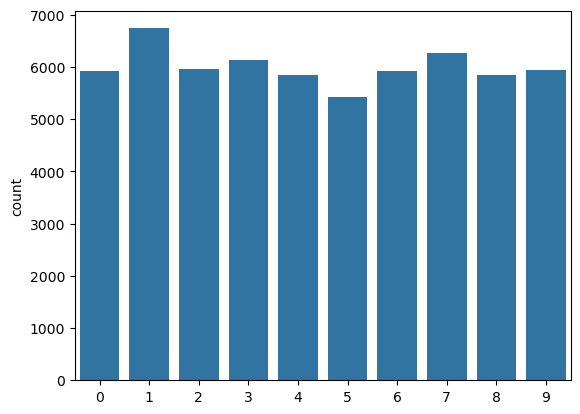

In [6]:
sns.countplot(x=y_train)
plt.show()

We can observe that the dataset has similar counts for each digit. This is good as the model will have enough images for each class to train the features for each class. There is no nedd to downsample or upweigh

## 2.2 Check for NaN Values

In [7]:
print(np.isnan(x_train).any())
print(np.isnan(x_test).any())
print(np.isnan(y_train).any())
print(np.isnan(y_test).any())

False
False
False
False


Since there is no NaN values on the dataset. We dont need to deal with them

## 2.3 Normalization and Reshaping

Since the values in our x_train are 28x28 images our input shape must be specified so that our model will know what is being imputed. The first convolution layer expects a signle 60000x28x28x2 tensor instead of 60000 28x28x1 tensors

Models generally run better on normalized values. The best way to normalize the data depends on each individual dataset. For the MNIST dataset, we want each value to be between 0.0 and 1.0, as all the values originally fall under rgb values, we will divide by 255.0

In [8]:
input_shape = (28, 28, 1)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], x_train.shape[2], 1))

x_train = x_train / 255.0

x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], x_test.shape[2], 1))

x_test = x_test / 255.0

## 2.4 Labels encoding
The labels for the training and the testing dataset are currently categorical and not continuos. To include categorical dataset in our model our labels should be converted to one-hot encodings.

For example, 2 becomes [0,0,1,0,0,0,0,0,0,0] and 7 becomes [0,0,0,0,0,0,0,1,0,0].

In [9]:
y_train = tf.one_hot(y_train.astype(np.int32), depth=10)
y_test = tf.one_hot(y_test.astype(np.int32), depth=10)

I0000 00:00:1759790489.792479   51316 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 2,5 Visualize Data

Lets see how the dataset looks

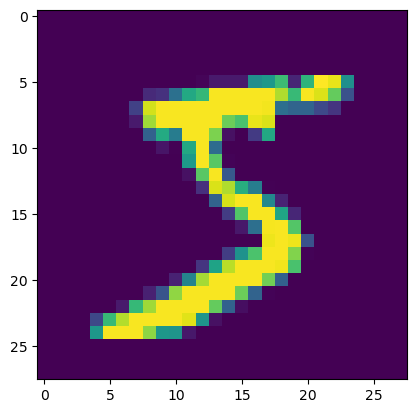

tf.Tensor([0. 0. 0. 0. 0. 1. 0. 0. 0. 0.], shape=(10,), dtype=float32)


In [10]:
plt.imshow(x_train[0].reshape(28,28))
plt.show()
print(y_train[0])

# 3. CNN
Lets build the CNN module

## 3.1 Define the model.

In [11]:
batch_size = 64
num_classes = 10
epochs = 5

Conv2D layers are convolutions. Each filter (32 in the first two convolution layers and 64 in the next two convolution layers) transforms a part of the image (5x5 for the first two Conv2D layers and 3x3 for the next two Conv2D layers). The transformation is applied on the whole image.

MaxPool2D is a downsampling filter. It reduces a 2x2 matrix of the image to a single pixel with the maximum value of the 2x2 matrix. The filter aims to conserve the main features of the image while reducing the size.

Dropout is a regularization layer. In our model, 25% of the nodes in the layer are randomly ignores, allowing the network to learn different features. This prevents overfitting.

relu is the rectifier, and it is used to find nonlinearity in the data. It works by returning the input value if the input value >= 0. If the input is negative, it returns 0.

Flatten converts the tensors into a 1D vector.

The Dense layers are an artificial neural network (ANN). The last layer returns the probability that an image is in each class (one for each digit).

As this model aims to categorize the images, we will use a categorical_crossentropy loss function.

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu', input_shape=input_shape),
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')])

model.compile(optimizer=tf.keras.optimizers.RMSprop(epsilon=1e-08), loss='categorical_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

/home/davas/miniconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 3.2 Fit the training data

The next step is to fit our training data. If we achive a certain level of accuracy, it may not be necessary to continue training the model. Especially if time and resources are limited.

The following cell defines a CallBack so that if 99.5% accuracy is achieved, the model stops training. The model is not likely to stop prematurely if only 5 epochs are specified.

In [13]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')>0.995):
            print("\nReached 99.5% accuracy so cancelling training!")
            self.model.stop_training = True

callbacks = myCallback()

Testing the model on a validation dataset prevents overfitting of the data. We specified a 10% validation and a 90% training split.

In [15]:
with tf.device('/GPU:0'):
    history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=10,
                    validation_split=0.1,
                    callbacks=[callbacks])

Epoch 1/10


2025-10-06 17:41:31.089606: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 169344000 exceeds 10% of free system memory.
2025-10-06 17:41:31.256244: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 169344000 exceeds 10% of free system memory.
2025-10-06 17:41:32.253260: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f1c28008e60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-06 17:41:32.253279: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2025-10-06 17:41:32.297422: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-06 17:41:32.253260: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f1c28008e60 initialized for platform CUDA (this does not gu

 28/844 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2560 - loss: 2.0709 - precision: 0.4026 - recall: 0.0574        

I0000 00:00:1759790496.340037   51494 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8409 - loss: 0.4827 - precision: 0.9110 - recall: 0.7942

2025-10-06 17:41:40.931011: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-06 17:41:41.258240: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1340', 4 bytes spill stores, 4 bytes spill loads

2025-10-06 17:41:41.258240: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1340', 4 bytes spill stores, 4 bytes spill loads

2025-10-06 17:41:41.461860: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1476', 8 bytes s

844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9301 - loss: 0.2254 - precision: 0.9565 - recall: 0.9137 - val_accuracy: 0.9860 - val_loss: 0.0478 - val_precision: 0.9871 - val_recall: 0.9852
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9301 - loss: 0.2254 - precision: 0.9565 - recall: 0.9137 - val_accuracy: 0.9860 - val_loss: 0.0478 - val_precision: 0.9871 - val_recall: 0.9852
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9779 - loss: 0.0776 - precision: 0.9808 - recall: 0.9758 - val_accuracy: 0.9873 - val_loss: 0.0424 - val_precision: 0.9883 - val_recall: 0.9870
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9779 - loss: 0.0776 - precision: 0.9808 - recall: 0.9758 - val_accuracy: 0.9873 - val_loss: 0.0424 - val_precision: 0.9883 - val_recall: 0.9870
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9841 - loss: 0.0577 - precision: 0.9854 - recall: 0.9827 - val_accuracy: 0.9923 - val_loss: 0.0307 - 

# 4. Evaluate the model

## 4.1 Loss and accuracy curves

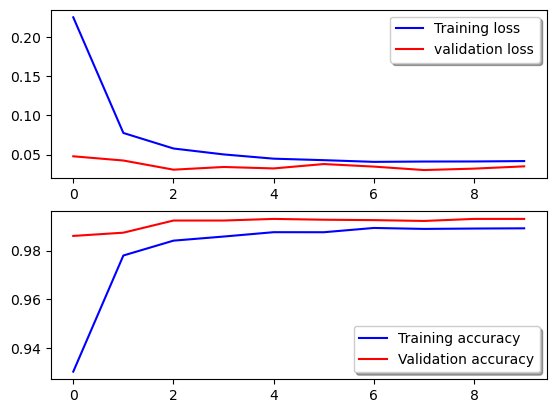

In [17]:
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss")
ax[0].legend(loc='best', shadow=True)
ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r', label="Validation accuracy")
ax[1].legend(loc='best', shadow=True)
plt.show()

The accuracy increaces over time and the loss decreases over time. However, the accuracy of our validation dataset seems to slightly decrease towards the end even though our training accuracy increased. Running the model for more epochs might cause our model to be susceptible to overfitting.

## 4.2 Predict Results

In [20]:
test_loss, test_acc, test_precision, test_recall = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9922 - loss: 0.0307 - precision: 0.9923 - recall: 0.9922
Test Loss: 0.030665762722492218
Test Accuracy: 0.9922000169754028
Test Precision: 0.9922992587089539
Test Recall: 0.9922000169754028


Our model runs pretty well. With an accuracy of 99.22% on our testing data

## 4.3 Confusion matrix

In [21]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

confusion = tf.math.confusion_matrix(labels=y_true, predictions=y_pred_classes)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Axes: >

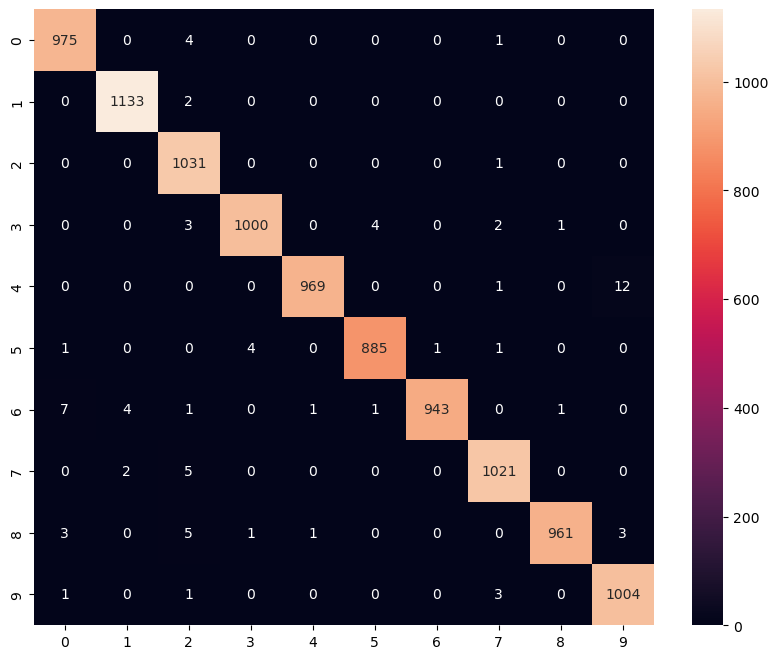

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion, annot=True, fmt='g')

There seems to be a slightly higer confusion between(4,9). Seems reasonable since both are pretty similar on the loops. And rounded edges can be mistaken.